In [1]:
import openbabel
from openbabel import pybel
import csv,sys
import pandas as pd
import numpy as np

In [2]:
SMARTS1=pd.read_csv('/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv')

In [3]:
SMARTS1['SMARTS']

0                                           [F,Cl,Br,I]
1                                                   [F]
2                                                  [Cl]
3                                                  [Br]
4                                                   [I]
5                                           [CX3]=[OX1]
6                                     [#6][CX3](=O)[#6]
7                                       [CX3H1](=O)[#6]
8                                [NX3][CX3](=[OX1])[#6]
9                              [#6][CX3](=O)[OX2H0][#6]
10                                     [CX3](=O)[OX2H1]
11    [$([cX3](:*):*),$([cX2+](:*):*),$([CX3]=*),$([...
12                                         [$([CX2]#C)]
13                     [$([cX3](:*):*),$([cX2+](:*):*)]
14                                          [NX1]#[CX2]
15                                 [NX3;H2,H1;!$(NC=O)]
16              [$([NX3](=O)=O),$([NX3+](=O)[O-])][!#8]
17                                          [NX2

In [4]:
#load dataset 
xgb_d2 = pd.read_csv('fps_xgboost_p_outliers2.csv')
rf_d2 = pd.read_csv('fps_rf_p_outliers_n2.csv')

In [5]:
#outputfile
Output="FG_hansen_p_xgb_d2.csv"

#Functional Group names 
FG_names=SMARTS1['FG']

#Get SMART CODES 
SMARTS_codes=SMARTS1['SMARTS']

#Get SMILES
smiles=xgb_d2['SMILES']
xgb_d2=np.array(xgb_d2)
FG_list=[]

for f in range(len(xgb_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(xgb_d2[f][5])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES
    
#for each molecule
for f in range(len(xgb_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(xgb_d2[f][5])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES
    for g in SMARTS_codes:
        smarts = pybel.Smarts(g)
        if smarts.findall(mol) == []:
            FG.append("0")
        else:
            FG.append("1")
    FG_list.append(FG)

FG_names2=list(FG_names) 
FG_names2.insert(0,"StdInChIKey") 
FG_list=pd.DataFrame(data=FG_list,columns=FG_names2) 

#this can then be outputted/merged or graphed 
FG_list.to_csv(Output,index=False)    

In [6]:
FG_list

,StdInChIKey,Halides,F,Cl,Br,I,Carbonyl,Ketone,Aldehyde,Amide,...,Alcohol,Ether inc. ester,P,S,Thiol,Thioamide,Sulfonamide,H-bond donor,Acidic hydroxyl,H-bond acceptor
0,10.321125,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-6.370608,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,8.952330,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,-11.773006,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-9.692294,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,6.312592,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,1,1
60,6.113959,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
61,-7.405455,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
62,6.765939,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
FG_sum_xgb_d2 = (FG_list.iloc[:,1:30].astype(int).sum())
FG_sum_xgb_d2_merge = (FG_sum_xgb_d2.to_frame('xgb_d2'))/len(xgb_d2)

In [8]:
FG_sum_xgb_d2_merge

,xgb_d2
Halides,0.218750
F,0.046875
Cl,0.140625
Br,0.031250
I,0.000000
Carbonyl,0.265625
Ketone,0.078125
Aldehyde,0.015625
Amide,0.046875
Ester,0.031250


In [9]:
#outputfile
Output="FG_hansen_p_rf_xgb_d2.csv"

#Functional Group names 
FG_names=SMARTS1['FG']

#Get SMART CODES 
SMARTS_codes=SMARTS1['SMARTS']

#Get SMILES
smiles=rf_d2['SMILES']
rf_d2=np.array(rf_d2)
FG_list=[]

for f in range(len(rf_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(rf_d2[f][4])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES

#for each molecule
for f in range(len(rf_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(rf_d2[f][4])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES
    for g in SMARTS_codes:
        smarts = pybel.Smarts(g)
        if smarts.findall(mol) == []:
            FG.append("0")
        else:
            FG.append("1")
    FG_list.append(FG)

FG_names2=list(FG_names) 
FG_names2.insert(0,"StdInChIKey") 
FG_list=pd.DataFrame(data=FG_list,columns=FG_names2) 

#this can then be outputted/merged or graphed 
FG_list.to_csv(Output,index=False)

In [10]:
FG_list

,StdInChIKey,Halides,F,Cl,Br,I,Carbonyl,Ketone,Aldehyde,Amide,...,Alcohol,Ether inc. ester,P,S,Thiol,Thioamide,Sulfonamide,H-bond donor,Acidic hydroxyl,H-bond acceptor
0,11.290000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4.965733,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2.864667,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,5.611000,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,8.470500,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,11.659000,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
62,10.118250,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,1,1
63,11.344000,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
64,11.746500,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
FG_sum_rf_d2 = FG_list.iloc[:,1:30].astype(int).sum()
FG_sum_rf_d2_merge = (FG_sum_rf_d2.to_frame('rf_d2'))/len(rf_d2)

In [12]:
FG_sum_rf_d2_merge

,rf_d2
Halides,0.181818
F,0.045455
Cl,0.121212
Br,0.015152
I,0.000000
Carbonyl,0.196970
Ketone,0.045455
Aldehyde,0.030303
Amide,0.000000
Ester,0.030303


In [13]:
SMARTS1 = pd.read_csv("/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv")

FG_names = SMARTS1['FG']
SMARTS_codes = SMARTS1['SMARTS']

In [14]:
FG_sum_hansen = pd.read_parquet('FG_sum_hansen.parquet')

In [15]:
FG_sum_hansen

,hansen
Halides,0.252747
F,0.047337
Cl,0.174979
Br,0.040575
I,0.007608
Carbonyl,0.294167
Ketone,0.054100
Aldehyde,0.027050
Amide,0.024514
Ester,0.120034


In [16]:
FG_sum_xgb_d2_merge ['xgb_d2'] =  FG_sum_xgb_d2_merge
FG_sum_xgb_d2_merge ['rf_d2'] =  FG_sum_rf_d2_merge
FG_sum_xgb_d2_merge ['hansen'] =  FG_sum_hansen

In [17]:
FG_sum_xgb_d2_merge

,xgb_d2,rf_d2,hansen
Halides,0.218750,0.181818,0.252747
F,0.046875,0.045455,0.047337
Cl,0.140625,0.121212,0.174979
Br,0.031250,0.015152,0.040575
I,0.000000,0.000000,0.007608
Carbonyl,0.265625,0.196970,0.294167
Ketone,0.078125,0.045455,0.054100
Aldehyde,0.015625,0.030303,0.027050
Amide,0.046875,0.000000,0.024514
Ester,0.031250,0.030303,0.120034


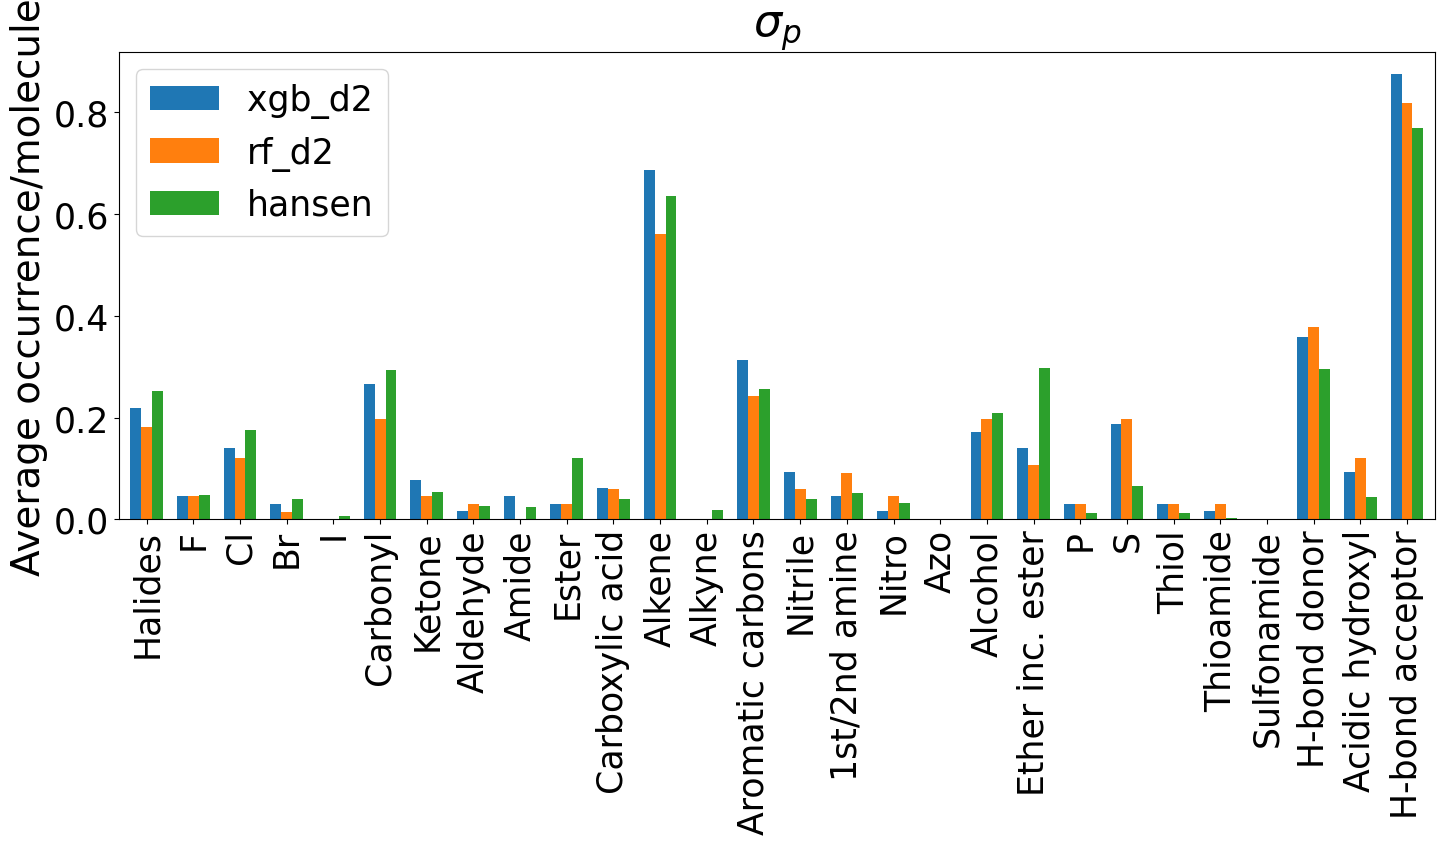

In [18]:
import matplotlib.pyplot as plt

# Set the default text font size
plt.rc('font', size=25)

ax = FG_sum_xgb_d2_merge.plot.bar(figsize=(15,9), width=0.7)

ax.set_ylabel("Average occurrence/molecule", size=28)

# Add sigma-p clearly as the title
ax.set_title(r'$\sigma_p$', size=32)

plt.tight_layout()
plt.show()

In [19]:
FG_sum_xgb_d2_merge['Random Forest'] = FG_sum_xgb_d2_merge['rf_d2']-FG_sum_xgb_d2_merge['hansen']
FG_sum_xgb_d2_merge['XGBoost'] = FG_sum_xgb_d2_merge['xgb_d2']-FG_sum_xgb_d2_merge['hansen']

In [20]:
FG_sum_xgb_d2_merge

,xgb_d2,rf_d2,hansen,Random Forest,XGBoost
Halides,0.218750,0.181818,0.252747,-0.070929,-0.033997
F,0.046875,0.045455,0.047337,-0.001883,-0.000462
Cl,0.140625,0.121212,0.174979,-0.053767,-0.034354
Br,0.031250,0.015152,0.040575,-0.025423,-0.009325
I,0.000000,0.000000,0.007608,-0.007608,-0.007608
Carbonyl,0.265625,0.196970,0.294167,-0.097198,-0.028542
Ketone,0.078125,0.045455,0.054100,-0.008645,0.024025
Aldehyde,0.015625,0.030303,0.027050,0.003253,-0.011425
Amide,0.046875,0.000000,0.024514,-0.024514,0.022361
Ester,0.031250,0.030303,0.120034,-0.089731,-0.088784


In [21]:
FG_sum_xgb_d2_merge_change = FG_sum_xgb_d2_merge[['Random Forest', 'XGBoost']]

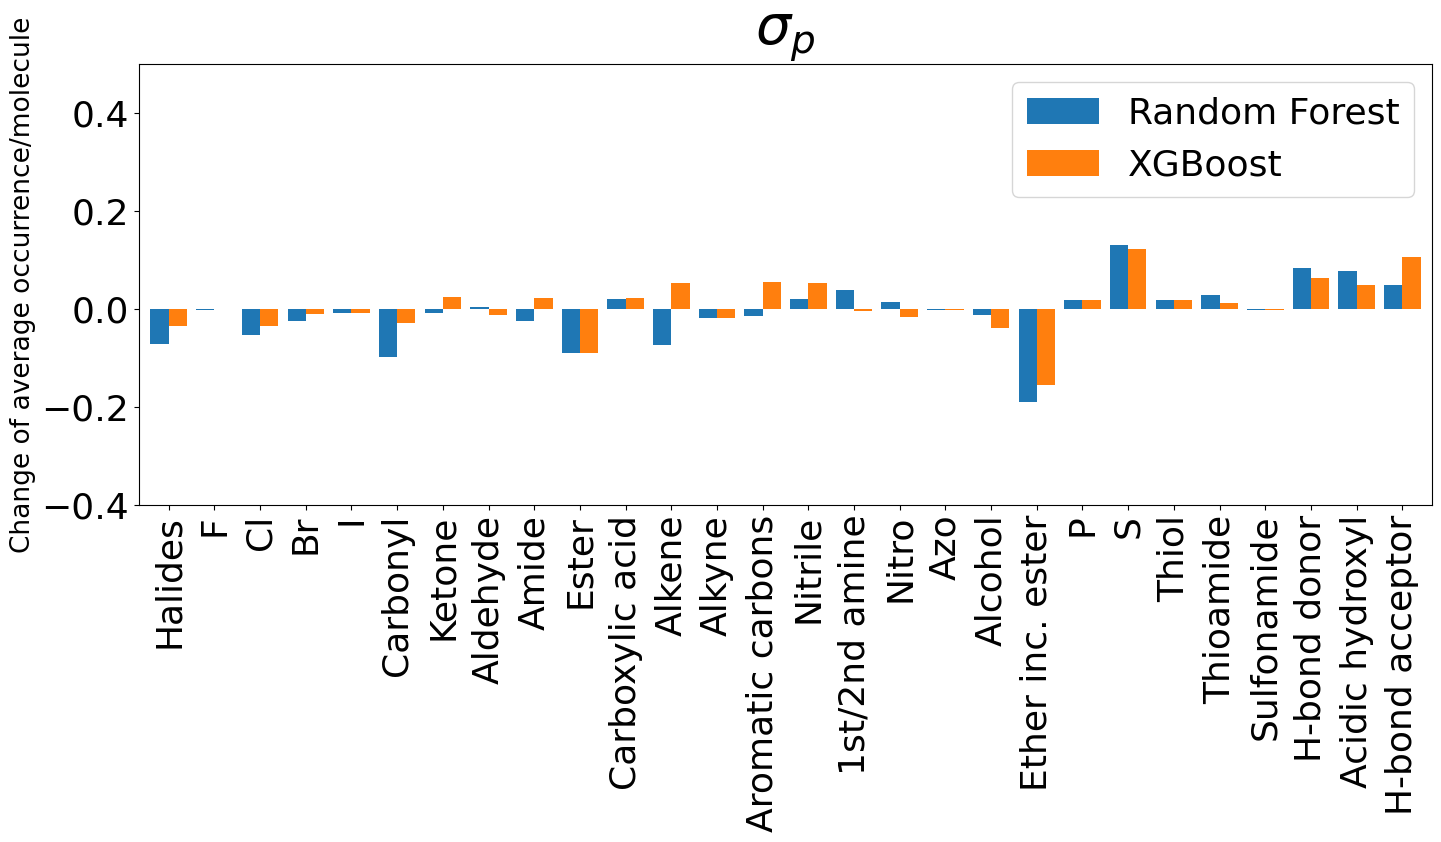

In [22]:
import matplotlib.pyplot as plt

# Set the default text font size
plt.rc('font', size=26)

ax = FG_sum_xgb_d2_merge_change.plot.bar(
    figsize=(15,9),
    ylim=(-0.4, 0.5),
    width=0.8
)

ax.set_ylabel("Change of average occurrence/molecule", size=19)

# Sigma-h title only
ax.set_title(r'$\sigma_p$', size=40)

plt.tight_layout()
plt.show()